In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import google.colab

In [2]:
sheets=pd.read_excel('/content/Regional_Sales_Dataset.xlsx', sheet_name=None)

In [192]:
# Name sheets

df_sales=sheets['Sales Orders']
df_customers=sheets['Customers']
df_products=sheets['Products']
df_regions=sheets['Regions']
df_state_reg=sheets['State Regions']
df_budgets=sheets['2017 Budgets']

In [4]:
df_regions.head(1)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago


In [5]:
df_state_reg.head(1)

,Column1,Column2,Column3
0,State Code,State,Region


In [6]:
new_header=df_state_reg.iloc[0]
df_state_reg.columns=new_header
df_state_reg=df_state_reg[1:].reset_index(drop=True)


In [7]:
df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


Merge Sheets

In [8]:
# Merge regions and state_reg sheets

df1=df_regions.merge(
    df_state_reg,
    how='left',
    left_on='state',
    right_on='State',
)
df1.head(1)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,State,Region
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago,AL,Alabama,South


In [9]:
df1.columns

Index(['id', 'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone', 'State Code', 'State',
       'Region'],
      dtype='object')

In [10]:

df1=df1.drop(columns=['State Code', 'State'])


In [11]:
list(df1.columns)

['id',
 'name',
 'county',
 'state_code',
 'state',
 'type',
 'latitude',
 'longitude',
 'area_code',
 'population',
 'households',
 'median_income',
 'land_area',
 'water_area',
 'time_zone',
 'Region']

In [12]:
# Next, Merge sales and customers sheets
df=df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)
list(df.columns)

['OrderNumber',
 'OrderDate',
 'Customer Name Index',
 'Channel',
 'Currency Code',
 'Warehouse Code',
 'Delivery Region Index',
 'Product Description Index',
 'Order Quantity',
 'Unit Price',
 'Line Total',
 'Total Unit Cost',
 'Customer Index',
 'Customer Names']

In [13]:
df=df.drop(columns=['Customer Index'], axis=1)

In [14]:
list(df.columns)

['OrderNumber',
 'OrderDate',
 'Customer Name Index',
 'Channel',
 'Currency Code',
 'Warehouse Code',
 'Delivery Region Index',
 'Product Description Index',
 'Order Quantity',
 'Unit Price',
 'Line Total',
 'Total Unit Cost',
 'Customer Names']

In [15]:
# Next, Merge df and products sheets

df2=df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [16]:
channel_sales = df2.groupby('Channel')['Total Unit Cost'].sum().reset_index()
channel_sales

,Channel,Total Unit Cost
0,Distributor,2.886643e+07
1,Export,1.328698e+07
2,Wholesale,4.964890e+07


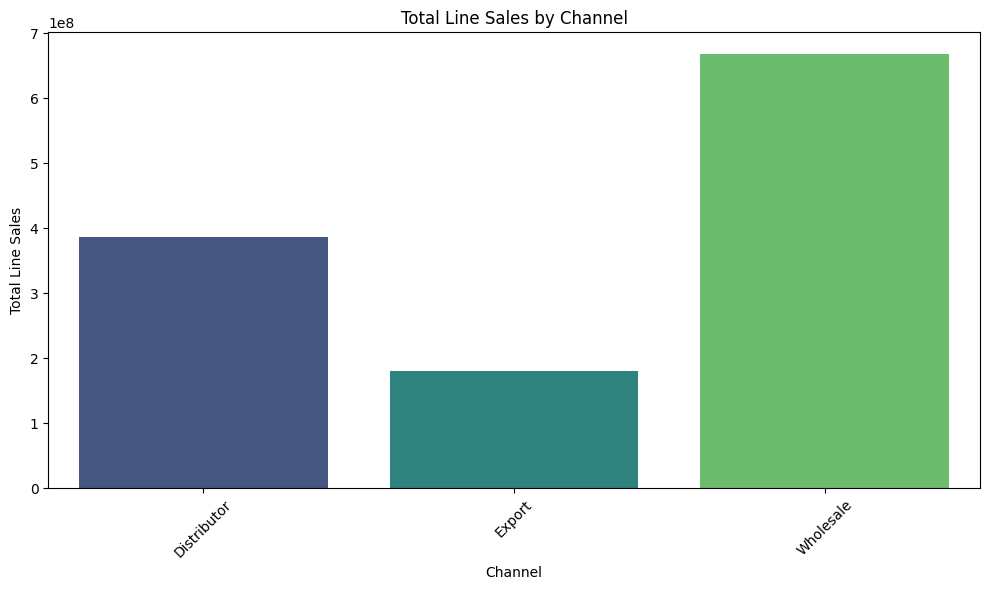

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Channel' and sum 'Line Total'
channel_sales = df2.groupby('Channel')['Line Total'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Channel', y='Line Total', data=channel_sales, palette='viridis', hue='Channel', legend=False)
plt.title('Total Line Sales by Channel')
plt.xlabel('Channel')
plt.ylabel('Total Line Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
list(df2.columns)

['OrderNumber',
 'OrderDate',
 'Customer Name Index',
 'Channel',
 'Currency Code',
 'Warehouse Code',
 'Delivery Region Index',
 'Product Description Index',
 'Order Quantity',
 'Unit Price',
 'Line Total',
 'Total Unit Cost',
 'Customer Names',
 'Index',
 'Product Name']

In [19]:
# Next, merge df2 and budgets sheets
df3=df2.merge(
    df_budgets,
    how='left',
    left_on='Product Name',
    right_on='Product Name'
)

In [20]:
list(df3.columns)

['OrderNumber',
 'OrderDate',
 'Customer Name Index',
 'Channel',
 'Currency Code',
 'Warehouse Code',
 'Delivery Region Index',
 'Product Description Index',
 'Order Quantity',
 'Unit Price',
 'Line Total',
 'Total Unit Cost',
 'Customer Names',
 'Index',
 'Product Name',
 '2017 Budgets']

In [21]:
# Next, final merge df3 and df1

df4=df3.merge(
    df1,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)


In [22]:
list(df4.columns)

['OrderNumber',
 'OrderDate',
 'Customer Name Index',
 'Channel',
 'Currency Code',
 'Warehouse Code',
 'Delivery Region Index',
 'Product Description Index',
 'Order Quantity',
 'Unit Price',
 'Line Total',
 'Total Unit Cost',
 'Customer Names',
 'Index',
 'Product Name',
 '2017 Budgets',
 'id',
 'name',
 'county',
 'state_code',
 'state',
 'type',
 'latitude',
 'longitude',
 'area_code',
 'population',
 'households',
 'median_income',
 'land_area',
 'water_area',
 'time_zone',
 'Region']

In [23]:
#null values....check
# no missing values

df4.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [24]:
df4.to_csv('output_file.csv', index=False)

In [25]:
df4['Index']

,Index
0,27
1,20
2,26
3,7
4,8
...,...
64099,26
64100,21
64101,13
64102,20


In [26]:
df4.drop('Index', axis=1, inplace=True)

In [27]:
list(df4.columns)

['OrderNumber',
 'OrderDate',
 'Customer Name Index',
 'Channel',
 'Currency Code',
 'Warehouse Code',
 'Delivery Region Index',
 'Product Description Index',
 'Order Quantity',
 'Unit Price',
 'Line Total',
 'Total Unit Cost',
 'Customer Names',
 'Product Name',
 '2017 Budgets',
 'id',
 'name',
 'county',
 'state_code',
 'state',
 'type',
 'latitude',
 'longitude',
 'area_code',
 'population',
 'households',
 'median_income',
 'land_area',
 'water_area',
 'time_zone',
 'Region']

In [28]:
# convert headers to lower case for ease of use

df4.columns=df4.columns.str.lower()
df4.columns

Index(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       '2017 budgets', 'id', 'name', 'county', 'state_code', 'state', 'type',
       'latitude', 'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region'],
      dtype='object')

In [29]:
df4.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       '2017 budgets', 'id', 'name', 'county', 'state_code', 'state',
       'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area',
       'time_zone', 'region'], dtype=object)

In [30]:
#Rename columns for better understanding and storytelling

df4=df4.rename(columns={'ordernumber': 'order_number', 'orderdate': 'order_date', 'order quantity':'order_quantity', 'unit price':'unit_price', 'line total':'revenue', 'total unit cost':'cost', 'customer names':'customer_name', 'product name':'product_name', '2017 budgets':'budget'})
df4.tail()

,order_number,order_date,customer name index,channel,currency code,warehouse code,delivery region index,product description index,order_quantity,unit_price,...,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,region
64099,SO - 0007573,2018-02-28,74,Wholesale,USD,AXW291,825,26,12,1815.7,...,40.15511,-74.82877,445,51326,18095,69878,26311722,253129,America/New York,Northeast
64100,SO - 0007706,2018-02-28,51,Export,USD,NXH382,444,21,6,864.3,...,42.11030,-88.03424,847,69308,26242,71573,35271964,370235,America/Chicago,Midwest
64101,SO - 0007718,2018-02-28,136,Distributor,USD,AXW291,312,13,11,3953.0,...,26.24453,-80.20644,954,57234,20651,42786,22943340,594611,America/New York,South
64102,SO - 0008084,2018-02-28,158,Distributor,USD,AXW291,737,20,7,3959.7,...,42.91002,-78.74182,716,87514,38912,48662,76228647,162756,America/New York,Northeast
64103,SO - 0008654,2018-02-28,22,Distributor,USD,AXW291,807,15,8,998.3,...,45.48706,-122.80371,503,96577,37238,56882,50563936,0,America/Los Angeles,West


In [31]:
df4.columns

Index(['order_number', 'order_date', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order_quantity', 'unit_price', 'revenue',
       'cost', 'customer_name', 'product_name', 'budget', 'id', 'name',
       'county', 'state_code', 'state', 'type', 'latitude', 'longitude',
       'area_code', 'population', 'households', 'median_income', 'land_area',
       'water_area', 'time_zone', 'region'],
      dtype='object')

In [32]:
#drop irrelevant columns and keep relevant ones by using 'cols_to_keep' or '.drop'

cols_to_keep=['order_number', 'order_date', 'customer_name', 'channel', 'product_name', 'order_quantity', 'unit_price', 'revenue', 'cost', 'state_code', 'state', 'county', 'region', 'latitude', 'longitude', 'budget']

In [33]:
yz=df4[cols_to_keep]
yz.head(1)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,state,county,region,latitude,longitude,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,Chatham County,South,32.08354,-81.09983,964940.231


In [34]:
df4.drop(columns=['Customer Name Index', 'Currency Code', 'Delivery Region Index', 'Product Description Index', 'area_code', 'Regio, 'Warehouse Code', 'water_area', 'population', 'type', 'land_area', 'time_zone', 'median_income', 'households', 'name'])
df4.head(1)

SyntaxError: unterminated string literal (detected at line 1) (3101333913.py, line 1)

In [35]:
yz.columns

Index(['order_number', 'order_date', 'customer_name', 'channel',
       'product_name', 'order_quantity', 'unit_price', 'revenue', 'cost',
       'state_code', 'state', 'county', 'region', 'latitude', 'longitude',
       'budget'],
      dtype='object')

In [36]:
yz
yz.to_csv('cleaned_file.csv', index=False)

In [37]:
#solve the 2017 budgets situation, since there are budgets for different years under order date, by separation

yz.loc[df4['order_date'].dt.year !=2017, 'budget']=pd.NA

#2017 budget values have been assigned 'NA' for undefined entries in a left join


In [38]:
yz.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,state,county,region,latitude,longitude,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,Chatham County,South,32.08354,-81.09983,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Johnson County,Midwest,39.61366,-86.10665,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,Alameda County,West,37.66243,-121.87468,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Monroe County,Midwest,39.16533,-86.52639,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Hartford County,Northeast,41.77524,-72.52443,NaN


In [39]:
df4.to_csv('output_data.csv', index=False)

In [41]:
yz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  object        
 1   order_date      64104 non-null  datetime64[ns]
 2   customer_name   64104 non-null  object        
 3   channel         64104 non-null  object        
 4   product_name    64104 non-null  object        
 5   order_quantity  64104 non-null  int64         
 6   unit_price      64104 non-null  float64       
 7   revenue         64104 non-null  float64       
 8   cost            64104 non-null  float64       
 9   state_code      64104 non-null  object        
 10  state           64104 non-null  object        
 11  county          64104 non-null  object        
 12  region          64104 non-null  object        
 13  latitude        64104 non-null  float64       
 14  longitude       64104 non-null  float64       
 15  bu

In [42]:
yz.head(5)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,state,county,region,latitude,longitude,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,Chatham County,South,32.08354,-81.09983,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Johnson County,Midwest,39.61366,-86.10665,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,Alameda County,West,37.66243,-121.87468,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Monroe County,Midwest,39.16533,-86.52639,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Hartford County,Northeast,41.77524,-72.52443,NaN


DATA QUALITY CHECK

In [43]:
# DATA CHECK

yz['calculated_revenue']=yz['order_quantity']*yz['unit_price']
yz['difference']=yz['calculated_revenue']-yz['revenue']
yz.head(1)

/tmp/ipykernel_2863/3906942374.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yz['calculated_revenue']=yz['order_quantity']*yz['unit_price']
/tmp/ipykernel_2863/3906942374.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yz['difference']=yz['calculated_revenue']-yz['revenue']


,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,state,county,region,latitude,longitude,budget,calculated_revenue,difference
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,Chatham County,South,32.08354,-81.09983,NaN,14994.6,0.0


Outliers

In [190]:

# Function to detect outliers
# =============================================
def detect_outliers(yz, column, method='iqr', threshold=1.5):
    if method == 'iqr':
        Q1 = yz[column].quantile(0.25)
        Q3 = yz[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        outliers = yz[(yz[column] < lower_bound) | (yz[column] > upper_bound)]
        print(f"\n{IQR} Method - {column}:")
        print(f"Lower bound: {lower_bound:.2f} | Upper bound: {upper_bound:.2f}")

    elif method == 'zscore':
        mean = yz[column].mean()
        std = yz[column].std()
        z_scores = np.abs((yz[column] - mean) / std)
        outliers = yz[z_scores > threshold]
        print(f"\nZ-Score Method - {column} (threshold = {threshold}):")

    print(f"Total outliers detected: {len(outliers)} out of {len(yz)} rows ({round(len(outliers)/len(df)*100, 2)}%)")
    return outliers

# =============================================
# Apply to Key Indicators
# =============================================

key_columns = ['unit_price', 'order_quantity']

for col in key_columns:
    outliers = detect_outliers(yz, col, method='iqr')
    if len(outliers) > 0:
        print("Sample Outliers:")
        print(outliers[['region', 'channel', 'product_name', col]].head(5))


# no outliers detected


2574.4750000000004 Method - unit_price:
Lower bound: -2829.91 | Upper bound: 7467.99
Total outliers detected: 0 out of 64104 rows (0.0%)

4.0 Method - order_quantity:
Lower bound: 0.00 | Upper bound: 16.00
Total outliers detected: 0 out of 64104 rows (0.0%)


In [44]:
yz.head(1)

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,state,county,region,latitude,longitude,budget,calculated_revenue,difference
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,Chatham County,South,32.08354,-81.09983,NaN,14994.6,0.0


Correlation Test

In [121]:
##check for relationship between revenue and order_quantity, unit_price in a particular region or by which channels


# Correlation by Region
region_corr = yz.groupby('region').apply(
    lambda x: x['unit_price'].corr(x['revenue'])
).round(4)

print("Correlation (unit price vs Revenue) by Region:")
print(region_corr)

Correlation (unit price vs Revenue) by Region:
region
Midwest      0.9100
Northeast    0.9086
South        0.9096
West         0.9087
dtype: float64


Stationarity Test

In [171]:
# 1. Check Stationarity
def check_stationarity(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    return result[1] < 0.05  # Stationary if True

print("Is data stationary?", check_stationarity(monthly_ts))

# 2. Build SARIMA Model
# (p,d,q) x (P,D,Q,s)   → s=12 for monthly seasonality
model = SARIMAX(monthly_ts,
                order=(1, 1, 1),              # Non-seasonal
                seasonal_order=(1, 1, 1, 12), # Seasonal (very important for you)
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)

print(results.summary())

ADF Statistic: -1.0842803760649582
p-value: 0.7212998266236573
Is data stationary? False
                                     SARIMAX Results                                      
Dep. Variable:                            revenue   No. Observations:                   50
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.360
Date:                            Sun, 28 Jun 2026   AIC                            704.720
Time:                                    18:42:16   BIC                            710.398
Sample:                                01-01-2014   HQIC                           706.148
                                     - 02-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1532    

In [170]:
yz.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,...,day,quarter,year_month,population,month_short,gross_profit,expected_revenue,revenue_diff,revenue_per_capita,order_value
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,2,2014Q1,2014-01,62059.0,Jan,13170.257,14994.6,0.0,0.241618,14994.6
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,2,2014Q1,2014-01,212461.0,Jan,24598.782,25868.7,0.0,0.121757,25868.7
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,2,2014Q1,2014-01,55437.0,Jan,5184.460,5869.2,0.0,0.105872,5869.2
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,2,2014Q1,2014-01,68567.0,Jan,15339.248,16368.1,0.0,0.238717,16368.1
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,2,2014Q1,2014-01,84848.0,Jan,17070.930,18331.2,0.0,0.216048,18331.2


Create date variants to find trend patterns


In [47]:
yz['year']=yz['order_date'].dt.year
yz['month']=yz['order_date'].dt.month
yz['day']=yz['order_date'].dt.day_of_week




/tmp/ipykernel_2863/15961615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yz['year']=yz['order_date'].dt.year
/tmp/ipykernel_2863/15961615.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yz['month']=yz['order_date'].dt.month
/tmp/ipykernel_2863/15961615.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

In [50]:
#Create Quarter and Year-Month columns
yz['quarter'] = yz['order_date'].dt.to_period('Q').astype(str)
yz['year_month'] =yz['order_date'].dt.to_period('M').astype(str)

/tmp/ipykernel_2863/3199608965.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yz['quarter'] = yz['order_date'].dt.to_period('Q').astype(str)
/tmp/ipykernel_2863/3199608965.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yz['year_month'] =yz['order_date'].dt.to_period('M').astype(str)


In [52]:
channel_2017 = (yz[yz['year'] == 2017])
channel_2017.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,...,latitude,longitude,budget,calculated_revenue,difference,year,month,day,quarter,year_month
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,...,40.77955,-74.02375,1011609.684,7437.0,0.0,2017,1,6,2017Q1,2017-01
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,...,39.06387,-108.55065,3720639.645,9145.5,0.0,2017,1,6,2017Q1,2017-01
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,...,33.96168,-118.35313,3299478.315,21708.0,0.0,2017,1,6,2017Q1,2017-01
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,...,42.50056,-90.66457,1085037.329,7236.0,0.0,2017,1,6,2017Q1,2017-01
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,...,28.47689,-82.52546,3050087.565,13346.4,0.0,2017,1,6,2017Q1,2017-01


Key Performance Indicators

REGION WITH THE LOWEST REVENUE

In [122]:
# Which region generates the lowest revenue?

# Revenue Contribution across regions
reg_contr = yz.groupby('region')['revenue'].sum().reset_index().sort_values('revenue', ascending=False)  # ← Important: reset_index()
reg_contr_all = yz['revenue'].sum()

# Add percentage column
reg_contr['percent'] = round(100 * reg_contr['revenue'] / reg_contr_all, 2)

# Show the table first
print(reg_contr)

#Answer: NORTHEAST

      region      revenue  percent
3       West  372142307.6    30.11
2      South  335135011.7    27.12
0    Midwest  320322363.6    25.92
1  Northeast  208369216.1    16.86


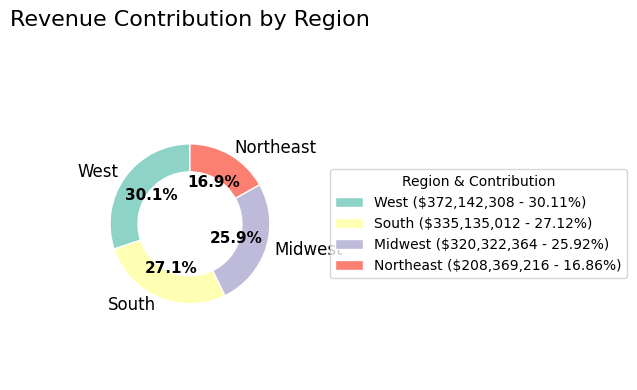

In [123]:

# ==================== DONUT CHART ====================
plt.figure(figsize=(6, 4))

wedges, texts, autotexts = plt.pie(reg_contr['revenue'],
                                  labels=reg_contr['region'],
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  colors=plt.cm.Set3.colors,
                                  wedgeprops=dict(width=0.35, edgecolor='white'))

plt.setp(autotexts, size=11, weight="bold")
plt.setp(texts, size=12)

plt.title('Revenue Contribution by Region', fontsize=16, pad=30)

# Legend
legend_labels = [f"{row['region']} (${row['revenue']:,.0f} - {row['percent']}%)"
                 for _, row in reg_contr.iterrows()]

plt.legend(legend_labels,
           title='Region & Contribution',
           loc='center left',
           bbox_to_anchor=(1, 0.5))

plt.axis('equal')
plt.tight_layout()
plt.show()

BEST PERFORMING PRODUCTS(TOP 5)

In [124]:
# which products generates the most revenue?

sku_contribution = yz.groupby('product_name').agg(
    total_revenue=('revenue', 'sum')
).reset_index()

total_rev = sku_contribution['total_revenue'].sum()
sku_contribution['revenue_contribution_pct'] = round(
    100 * sku_contribution['total_revenue'] / total_rev, 2
)

sku_contribution = sku_contribution.sort_values('total_revenue', ascending=False)
sku_contribution['cumulative_pct'] = round(sku_contribution['revenue_contribution_pct'].cumsum(), 2)

print("Top 5 SKUs by Revenue Contribution:")
print(sku_contribution.head(5))

Top 5 SKUs by Revenue Contribution:
   product_name  total_revenue  revenue_contribution_pct  cumulative_pct
18   Product 26    117291821.4                      9.49            9.49
17   Product 25    109473966.6                      8.86           18.35
4    Product 13     78281379.6                      6.33           24.68
5    Product 14     75390396.6                      6.10           30.78
25    Product 5     70804380.6                      5.73           36.51


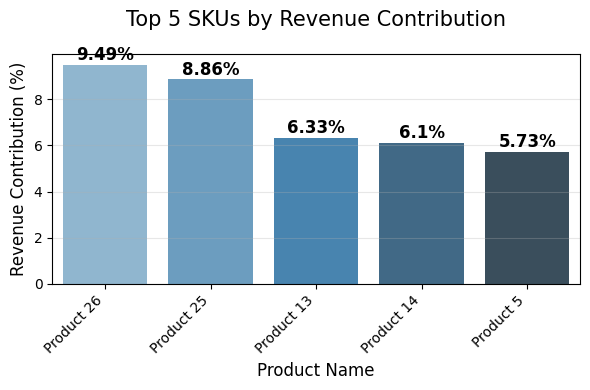

In [153]:

data = {
    'product_name': ['Product 26', 'Product 25', 'Product 13', 'Product 14', 'Product 5'],
    'total_revenue': [117291821.4, 109473966.6, 78281379.6, 75390396.6, 70804380.6],
    'revenue_contribution_pct': [9.49, 8.86, 6.33, 6.10, 5.73],
    'cumulative_pct': [9.49, 18.35, 24.68, 30.78, 36.51]
}

top_skus = pd.DataFrame(data)

# === Bar Chart (without red cumulative line) ===
plt.figure(figsize=(6, 4))

bars = sns.barplot(x='product_name', y='revenue_contribution_pct',
                   data=top_skus, palette='Blues_d')

plt.title('Top 5 SKUs by Revenue Contribution', fontsize=15, pad=20)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Revenue Contribution (%)', fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of bars
for i, v in enumerate(top_skus['revenue_contribution_pct']):
    plt.text(i, v + 0.2, f"{v}%", ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

WORST PERFORMING PRODUCTS(BOTTOM 5)

In [146]:
# which products generates the most revenue?

sku_contribution = yz.groupby('product_name').agg(
    total_revenue=('revenue', 'sum')
).reset_index()

total_rev = sku_contribution['total_revenue'].sum()
sku_contribution['revenue_contribution_pct'] = round(
    100 * sku_contribution['total_revenue'] / total_rev, 2
)

sku_contribution = sku_contribution.sort_values('total_revenue', ascending=False)
sku_contribution['cumulative_pct'] = round(sku_contribution['revenue_contribution_pct'].cumsum(), 2)

print("Bottom 5 SKUs by Revenue Contribution:")
print(sku_contribution.tail(5))

Bottom 5 SKUs by Revenue Contribution:
   product_name  total_revenue  revenue_contribution_pct  cumulative_pct
27    Product 7     17058267.0                      1.38           95.16
14   Product 22     15638202.0                      1.27           96.43
21   Product 29     15311014.2                      1.24           97.67
29    Product 9     14598630.0                      1.18           98.85
16   Product 24     14555053.2                      1.18          100.03


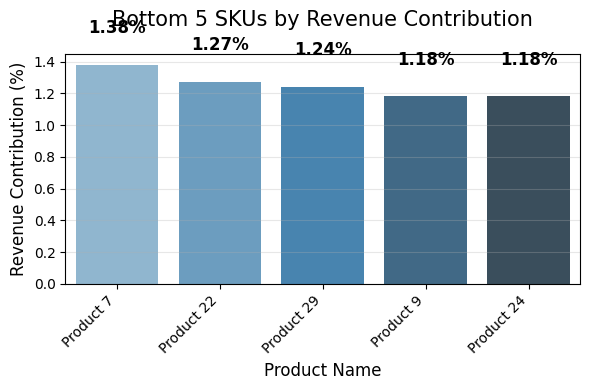

In [161]:

data = {
    'product_name': ['Product 7', 'Product 22', 'Product 29', 'Product 9', 'Product 24'],
    'total_revenue': [17058267.0, 15638202.0, 15311014.2, 14598630.0, 14555053.2],
    'revenue_contribution_pct': [1.38, 1.27, 1.24, 1.18, 1.18],
    'cumulative_pct': [1.38, 2.65, 3.89, 5.07, 6.25]
}

bottom_skus = pd.DataFrame(data)

# === Bar Chart (without red cumulative line) ===
plt.figure(figsize=(6, 4))

bars = sns.barplot(x='product_name', y='revenue_contribution_pct',
                   data=bottom_skus, palette='Blues_d')

plt.title('Bottom 5 SKUs by Revenue Contribution', fontsize=15, pad=20)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Revenue Contribution (%)', fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add percentage labels on top of bars
for i, v in enumerate(bottom_skus['revenue_contribution_pct']):
    plt.text(i, v + 0.2, f"{v}%", ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

CHANNEL PRODUCTIVITY

In [127]:
# Which channnel has the lowest productivity?

channel_2016 = channel_profitability.xs(2016, level='year').sort_values(ascending=False).reset_index()
channel_2016.head(1)
print(channel_2016)

# Calculate percentage of total
total = channel_2016.iloc[:, 1].sum()   # assuming 2nd column is the value
channel_2016['Percentage'] = (channel_2016.iloc[:, 1] / total * 100).round(2)

# Rename columns for better readability (adjust names if needed)
channel_2016.columns = ['Channel', 'Profit', 'Percentage (%)']

# Display as nice formatted table
print("=== CHANNEL PROFITABILITY 2016 ===\n")
display(channel_2016.style
        .format({
            'Profit': '{:,.2f}',
            'Percentage (%)': '{:.2f}%'
        }))


#Answer: Export


       channel      revenue
0    Wholesale  160574109.5
1  Distributor   93352761.6
2       Export   44156798.9
=== CHANNEL PROFITABILITY 2016 ===



,Channel,Profit,Percentage (%)
0,Wholesale,"160,574,109.50",53.87%
1,Distributor,"93,352,761.60",31.32%
2,Export,"44,156,798.90",14.81%


In [130]:
channel_profitability=yz.groupby(['channel', 'year'])['revenue'].sum()
channel_profitability.head(30)


channel      year
Distributor  2014     93704123.0
             2015     92229131.4
             2016     93352761.6
             2017     92961582.1
             2018     14892190.5
Export       2014     42523928.5
             2015     44028453.7
             2016     44156798.9
             2017     42664072.4
             2018      7258612.5
Wholesale    2014    161292677.8
             2015    162153125.3
             2016    160574109.5
             2017    158198182.3
             2018     25979149.5
Name: revenue, dtype: float64

In [126]:

# === Revenue Contribution by Region & Channel ===
region_channel_contrib = yz.groupby(['region', 'channel']).agg(
    total_revenue=('revenue', 'sum'),
    total_units=('order_quantity', 'sum'),
    unique_customers=('customer_name', 'nunique')
).reset_index()

# Calculate Average Order Value (after groupby)
region_channel_contrib['avg_order_value'] = (
    region_channel_contrib['total_revenue'] / region_channel_contrib['unique_customers']
)

# Calculate overall contribution %
total_revenue_all = region_channel_contrib['total_revenue'].sum()

region_channel_contrib['revenue_contribution_pct'] = round(
    100 * region_channel_contrib['total_revenue'] / total_revenue_all, 2
)

# Sort by highest revenue
region_channel_contrib = region_channel_contrib.sort_values(
    'total_revenue', ascending=False
).reset_index(drop=True)

# Reorder columns
region_channel_contrib = region_channel_contrib[[
    'region', 'channel', 'total_revenue', 'revenue_contribution_pct',
    'total_units', 'unique_customers', 'avg_order_value'
]]

print("Revenue Contribution % by Region & Channel:")
print(region_channel_contrib.round(2))

Revenue Contribution % by Region & Channel:
       region      channel  total_revenue  revenue_contribution_pct  \
0        West    Wholesale    202603631.6                     16.39   
1       South    Wholesale    179070377.4                     14.49   
2     Midwest    Wholesale    175050993.8                     14.16   
3        West  Distributor    115443760.4                      9.34   
4   Northeast    Wholesale    111472241.6                      9.02   
5       South  Distributor    106180621.8                      8.59   
6     Midwest  Distributor    100122012.8                      8.10   
7   Northeast  Distributor     65393393.6                      5.29   
8        West       Export     54094915.6                      4.38   
9       South       Export     49884012.5                      4.04   
10    Midwest       Export     45149357.0                      3.65   
11  Northeast       Export     31503580.9                      2.55   

    total_units  unique_customer

**Revenue Contribution by region x channel**

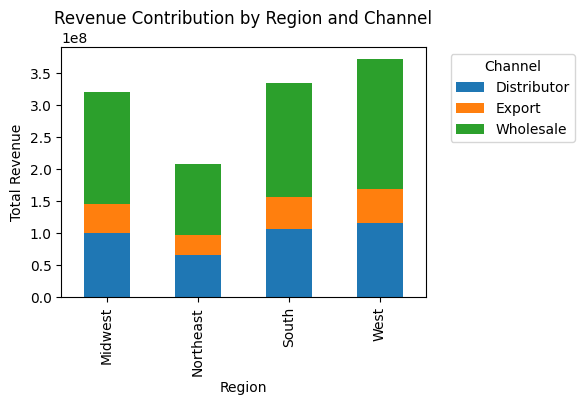

In [129]:

# Pivot for stacked visualization
pivot_data = region_channel_contrib.pivot(index='region',
                                          columns='channel',
                                          values='total_revenue')

pivot_data.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Revenue Contribution by Region and Channel')
plt.ylabel('Total Revenue')
plt.xlabel('Region')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [133]:
#Revenue by region and time
# === AGGREGATION AT REGION + year LEVEL ===
region_month_agg = yz.groupby(['region', 'year']).agg(
    total_revenue=('revenue', 'sum'),
    total_units=('order_quantity', 'sum'),
    total_orders=('customer_name', 'nunique'),        # Number of unique customers (proxy for orders)
    avg_unit_price=('unit_price', 'mean'),
    avg_order_quantity=('order_quantity', 'mean'),
    order_count=('customer_name', 'count')            # Total order lines
).reset_index()

# Sort by Region and Time
region_month_agg = region_month_agg.sort_values(['region', 'year'])

print("Region + Year Level Aggregation Preview:")
print(region_month_agg.head(10))

Region + Year Level Aggregation Preview:
      region  year  total_revenue  total_units  total_orders  avg_unit_price  \
0    Midwest  2014     77935210.7        33891           175     2302.175568   
1    Midwest  2015     77402527.2        33820           175     2283.375757   
2    Midwest  2016     76440152.6        33586           175     2276.765039   
3    Midwest  2017     76538850.3        33387           175     2289.466171   
4    Midwest  2018     12005622.8         5369           172     2226.651115   
5  Northeast  2014     48993863.9        21815           175     2247.112922   
6  Northeast  2015     50453304.8        21706           175     2320.889437   
7  Northeast  2016     51449420.6        21588           175     2378.842584   
8  Northeast  2017     48958266.8        21362           175     2293.983833   
9  Northeast  2018      8514360.0         3533           157     2422.489078   

   avg_order_quantity  order_count  
0            8.466400         4003  
1   

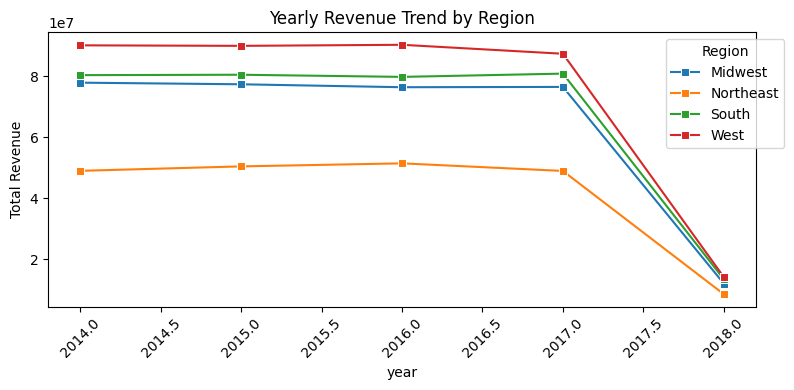

In [134]:

plt.figure(figsize=(8, 4))
sns.lineplot(data=region_month_agg, x='year', y='total_revenue', hue='region', marker='s')
plt.title('Yearly Revenue Trend by Region')
plt.xticks(rotation=45)
plt.ylabel('Total Revenue')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [176]:
#Which product sell best in each region? Northeast, Midwest, West, South


region_profitability=yz.groupby(['region', 'product_name'])['revenue'].sum()
region_profitability.head(5)

reg_northeast = region_profitability.xs('South', level='region').sort_values(ascending=False).reset_index()
reg_northeast.head(1)
print(reg_northeast)

# Calculate percentage of total
total = reg_northeast.iloc[:, 1].sum()   # assuming 2nd column is the value
reg_northeast['Percentage'] = (reg_northeast.iloc[:, 1] / total * 100).round(2)

# Rename columns for better readability (adjust names if needed)
reg_northeast.columns = ['region', 'Profit', 'Percentage (%)']

# Display as nice formatted table
print("=== Region and Products ===\n")
display(reg_northeast.style
        .format({
            'Profit': '{:,.2f}',
            'Percentage (%)': '{:.2f}%'
        }))

# Product 26 sells the best in West, South and Midwest regions. Product 25 sells the best in the Northeast region, only by a slight margin.

#Recommendation: increase marketing in region northeast,

   product_name     revenue
0    Product 26  31327350.8
1    Product 25  30651407.9
2    Product 13  21056987.8
3    Product 14  19601694.2
4     Product 5  19031725.2
5    Product 15  18681924.9
6     Product 1  15829158.7
7     Product 2  15564816.9
8     Product 4  15231110.0
9     Product 3  14355198.9
10   Product 18  13825282.5
11    Product 6  10750552.0
12   Product 20  10703357.2
13   Product 17  10570931.7
14   Product 16   9876356.1
15   Product 19   9115778.8
16   Product 11   6143183.1
17   Product 12   6011487.9
18    Product 8   5397942.1
19   Product 28   5335364.1
20   Product 23   5251594.0
21    Product 7   5052604.0
22   Product 27   5047317.7
23   Product 21   4907200.6
24    Product 9   4639951.0
25   Product 22   4634785.3
26   Product 10   4481603.2
27   Product 30   4448974.2
28   Product 29   4084206.1
29   Product 24   3525164.8
=== Region and Products ===



,region,Profit,Percentage (%)
0,Product 26,"31,327,350.80",9.35%
1,Product 25,"30,651,407.90",9.15%
2,Product 13,"21,056,987.80",6.28%
3,Product 14,"19,601,694.20",5.85%
4,Product 5,"19,031,725.20",5.68%
5,Product 15,"18,681,924.90",5.57%
6,Product 1,"15,829,158.70",4.72%
7,Product 2,"15,564,816.90",4.64%
8,Product 4,"15,231,110.00",4.54%
9,Product 3,"14,355,198.90",4.28%


TOTAL REVENUE

In [165]:
yz['revenue'].sum().round(5)

# 1.24B

np.float64(1235968899.0)

TOTAL ORDERS

In [166]:
# Sum of order_quantity
yz['order_quantity'].sum()

# 54.1146k

np.int64(541146)

GROSS PROFIT

In [169]:
yz['gross_profit']=yz['revenue']-yz['cost']
yz['gross_profit'].sum().round()

# 1.14b

np.float64(1144166593.0)

In [53]:
region_northeast=(yz[yz['region']=='Northeast'])
region_northeast.head()

,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,...,latitude,longitude,budget,calculated_revenue,difference,year,month,day,quarter,year_month
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,41.77524,-72.52443,NaN,18331.2,0.0,2014,1,2,2014Q1,2014-01
6,SO - 0008865,2014-01-01,Kare Corp,Wholesale,Product 1,7,2874.3,20120.1,1667.094,MA,...,42.32385,-71.14200,NaN,20120.1,0.0,2014,1,2,2014Q1,2014-01
15,SO - 0001068,2014-01-01,Fatz Group,Export,Product 10,11,924.6,10170.6,656.466,NY,...,40.71258,-73.19552,NaN,10170.6,0.0,2014,1,2,2014Q1,2014-01
17,SO - 0002504,2014-01-01,Colgate-Pa Group,Export,Product 27,11,1976.5,21741.5,790.600,PA,...,40.44062,-79.99589,NaN,21741.5,0.0,2014,1,2,2014Q1,2014-01
27,SO - 0005121,2014-01-01,Twitterbri Ltd,Wholesale,Product 30,6,5681.6,34089.6,4090.752,MA,...,42.37510,-71.10561,NaN,34089.6,0.0,2014,1,2,2014Q1,2014-01


In [132]:
region_profitability=yz.groupby(['region', 'product_name'])['revenue'].sum()
region_profitability


region   product_name
Midwest  Product 1       14352619.4
         Product 10       4486333.4
         Product 11       5623544.5
         Product 12       6293785.7
         Product 13      19631113.9
                            ...    
West     Product 5       20176715.0
         Product 6       12066378.4
         Product 7        5130257.0
         Product 8        6104269.5
         Product 9        4329640.5
Name: revenue, Length: 120, dtype: float64

In [60]:
#population is missing
#restore dataframe[population]
yz['population'] = df1['population']

/tmp/ipykernel_2863/1925393951.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yz['population'] = df1['population']


**MoM growth trend by channel**

In [67]:
# By Channel
channel_yearly = yz.groupby(['year', 'channel'])['revenue'].sum().reset_index()

channel_yearly = channel_yearly.sort_values(['channel', 'year'])
channel_yearly['YoY_growth_pct'] = channel_yearly.groupby('channel')['revenue'].pct_change() * 100
channel_yearly['Yoy_growth_pct'] = round(channel_yearly['YoY_growth_pct'], 2)

print("\n=== Channel Yearly Growth ===")
print(channel_yearly[['year', 'channel', 'revenue', 'YoY_growth_pct']].head(20))

# Insight: Year over year growth is non-existent with no significant changes from 2014-2017


=== Channel Yearly Growth ===
    year      channel      revenue  YoY_growth_pct
0   2014  Distributor   93704123.0             NaN
3   2015  Distributor   92229131.4       -1.574095
6   2016  Distributor   93352761.6        1.218303
9   2017  Distributor   92961582.1       -0.419034
12  2018  Distributor   14892190.5      -83.980274
1   2014       Export   42523928.5             NaN
4   2015       Export   44028453.7        3.538067
7   2016       Export   44156798.9        0.291505
10  2017       Export   42664072.4       -3.380513
13  2018       Export    7258612.5      -82.986592
2   2014    Wholesale  161292677.8             NaN
5   2015    Wholesale  162153125.3        0.533470
8   2016    Wholesale  160574109.5       -0.973781
11  2017    Wholesale  158198182.3       -1.479645
14  2018    Wholesale   25979149.5      -83.578099


In [68]:
yz['month_short'] = yz['order_date'].dt.strftime('%b')
yz['month_short']
yz['year_month']

/tmp/ipykernel_2863/295719590.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yz['month_short'] = yz['order_date'].dt.strftime('%b')


,year_month
0,2014-01
1,2014-01
2,2014-01
3,2014-01
4,2014-01
...,...
64099,2018-02
64100,2018-02
64101,2018-02
64102,2018-02


In [69]:
yz.columns

Index(['order_number', 'order_date', 'customer_name', 'channel',
       'product_name', 'order_quantity', 'unit_price', 'revenue', 'cost',
       'state_code', 'state', 'county', 'region', 'latitude', 'longitude',
       'budget', 'calculated_revenue', 'difference', 'year', 'month', 'day',
       'quarter', 'year_month', 'population', 'month_short'],
      dtype='object')

PEAK SEASONS & LOW SEASONS


In [181]:
# Seasonality Index by month

# Calculate monthly revenue
monthly_revenue = yz.groupby('month_short')['revenue'].sum().reset_index()

# Calculate average monthly revenue (overall)
average_monthly_revenue = monthly_revenue['revenue'].mean()

# Calculate Seasonal Index
monthly_revenue['seasonal_index'] = round(
    monthly_revenue['revenue'] / average_monthly_revenue, 2
)

# Sort months in correct order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_revenue = monthly_revenue.set_index('month_short').reindex(month_order).reset_index()

print("Seasonal Index by month")
print(monthly_revenue[['month_short', 'revenue', 'seasonal_index']])

# peak season: January, with a 20% above average performance; and Febrauary.
# low season: April, Jun, July with a below average performance of 6-8

Seasonal Index by month
   month_short      revenue  seasonal_index
0          Jan  124111403.0            1.20
1          Feb  114747751.0            1.11
2          Mar  100613652.1            0.98
3          Apr   95224755.0            0.92
4          May  102272116.5            0.99
5          Jun   96912692.7            0.94
6          Jul   97185201.8            0.94
7          Aug  101947025.8            0.99
8          Sep   99432301.4            0.97
9          Oct  100988872.2            0.98
10         Nov  101285199.8            0.98
11         Dec  101247927.7            0.98


Seasonal Index by Region & Channel

In [182]:
# Calculate average revenue per month for each region
monthly_region = yz.groupby(['channel', 'month_short', 'year'])['revenue'].sum().reset_index()

avg_monthly_region = monthly_region.groupby(['channel', 'month_short'])['revenue'].mean().reset_index()
avg_monthly_region = avg_monthly_region.rename(columns={'revenue': 'avg_revenue'})

# Calculate overall average revenue per region
overall_avg = avg_monthly_region.groupby('channel')['avg_revenue'].mean().reset_index()
overall_avg = overall_avg.rename(columns={'avg_revenue': 'overall_avg'})

# Merge and calculate Seasonal Index
heatmap_data = pd.merge(avg_monthly_region, overall_avg, on='channel')
heatmap_data['seasonal_index'] = round(heatmap_data['avg_revenue'] / heatmap_data['overall_avg'], 2)

# Pivot for heatmap
heatmap_pivot = heatmap_data.pivot(index='month_short', columns='channel', values='seasonal_index')

# Order months correctly
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_pivot = heatmap_pivot.reindex(month_order)



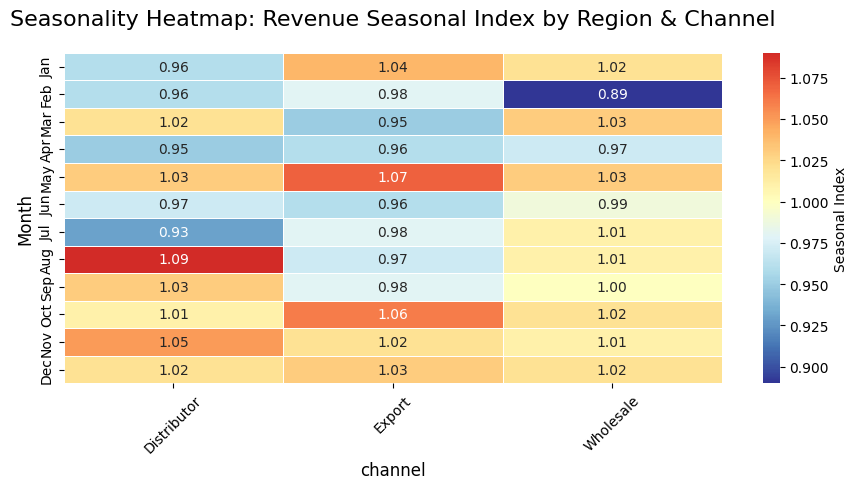

In [184]:
# ==================== PLOT HEATMAP ====================
plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_pivot,
            annot=True,
            fmt='.2f',
            cmap='RdYlBu_r',        # Red = low, Blue = high
            center=1.0,
            linewidths=0.5,
            cbar_kws={'label': 'Seasonal Index'})

plt.title('Seasonality Heatmap: Revenue Seasonal Index by Region & Channel', fontsize=16, pad=20)
plt.xlabel('channel', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [177]:

import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# =============================================
# Prepare Monthly Time Series
# =============================================
yz['order_date'] = pd.to_datetime(yz['order_date'])

monthly_ts = yz.groupby(yz['order_date'].dt.to_period('M'))['revenue'].sum()
monthly_ts = monthly_ts.to_timestamp()   # Convert to datetime index

print("Data ready for SARIMA. Shape:", monthly_ts.shape)

Data ready for SARIMA. Shape: (50,)


In [80]:
yz.groupby(['region', 'year'])['revenue'].sum()
#

region     year
Midwest    2014    77935210.7
           2015    77402527.2
           2016    76440152.6
           2017    76538850.3
           2018    12005622.8
Northeast  2014    48993863.9
           2015    50453304.8
           2016    51449420.6
           2017    48958266.8
           2018     8514360.0
South      2014    80403041.8
           2015    80536485.7
           2016    79830627.3
           2017    80903002.5
           2018    13461854.4
West       2014    90188612.9
           2015    90018392.7
           2016    90363469.5
           2017    87423717.2
           2018    14148115.3
Name: revenue, dtype: float64

In [178]:
# Monthly Aggregations
monthly_total = yz.groupby('year_month').agg({
    'revenue': 'sum',
    'order_quantity': 'sum',
    'customer_name': 'nunique'
}).reset_index()

# By Region
monthly_by_region = yz.groupby(['year_month', 'region']).agg({
    'revenue': 'sum'
}).reset_index()

# By Channel
monthly_by_channel = yz.groupby(['year_month', 'channel']).agg({
    'revenue': 'sum'
})

PREDICTIVE ANALYSIS

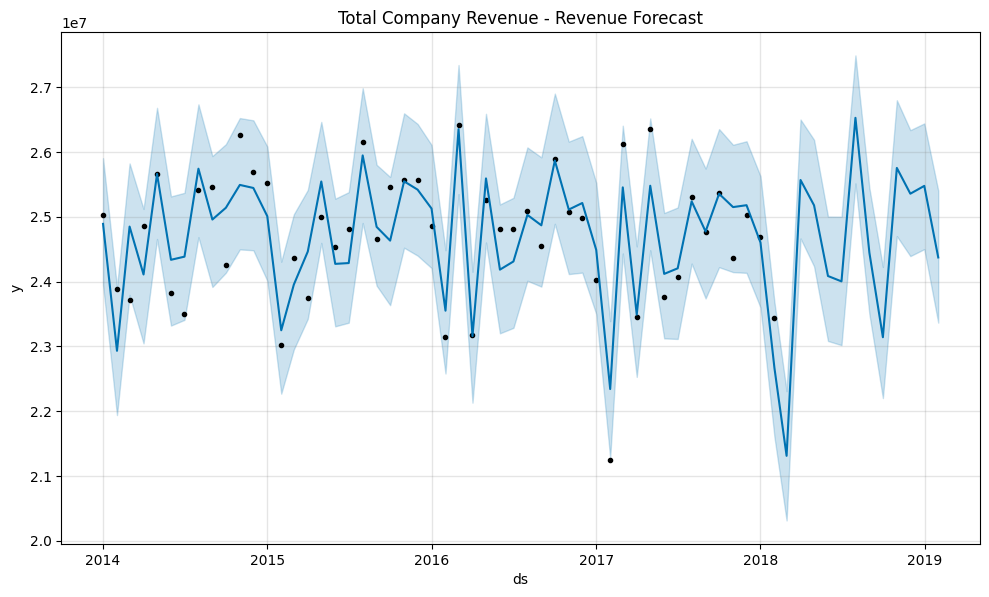


=== Total Company Revenue Forecast ===
Next 3 Months Expected Revenue: $72,054,656
Next 6 Months Expected Revenue: $146,669,409
Next 12 Months Expected Revenue: $295,212,944


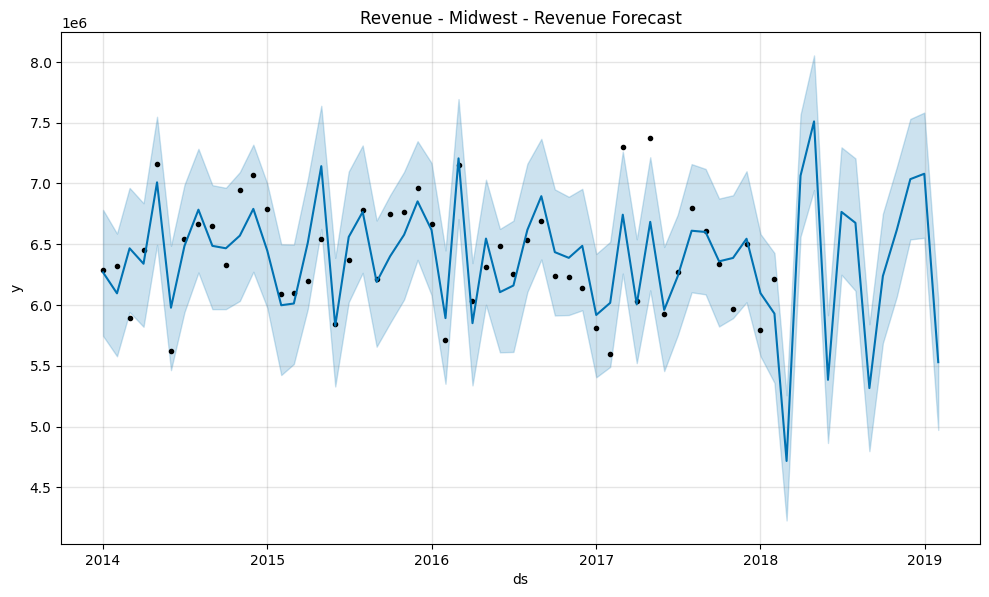


=== Revenue - Midwest Forecast ===
Next 3 Months Expected Revenue: $19,291,143
Next 6 Months Expected Revenue: $38,116,858
Next 12 Months Expected Revenue: $75,934,521


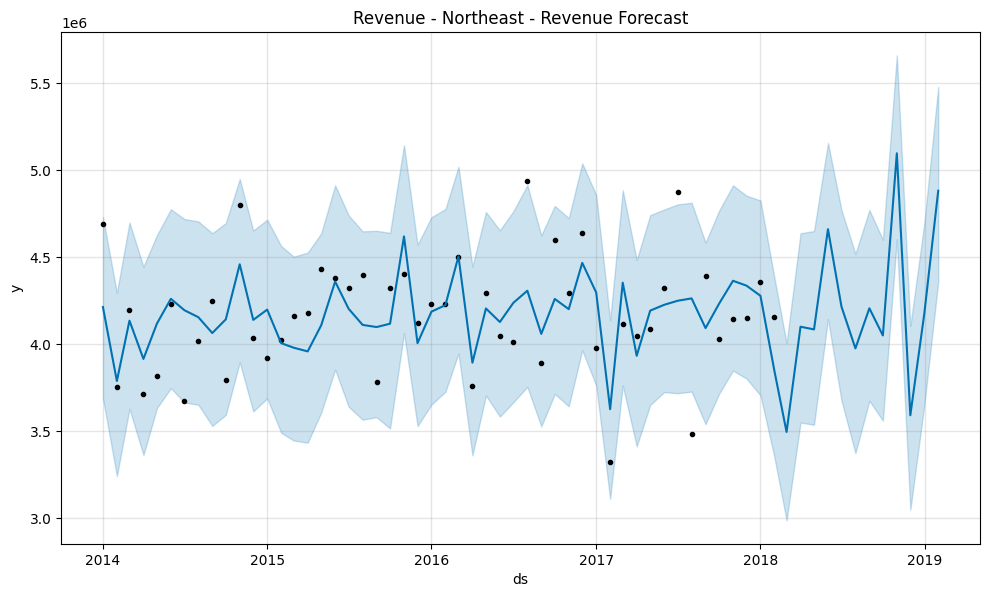


=== Revenue - Northeast Forecast ===
Next 3 Months Expected Revenue: $11,684,117
Next 6 Months Expected Revenue: $24,539,637
Next 12 Months Expected Revenue: $50,546,592


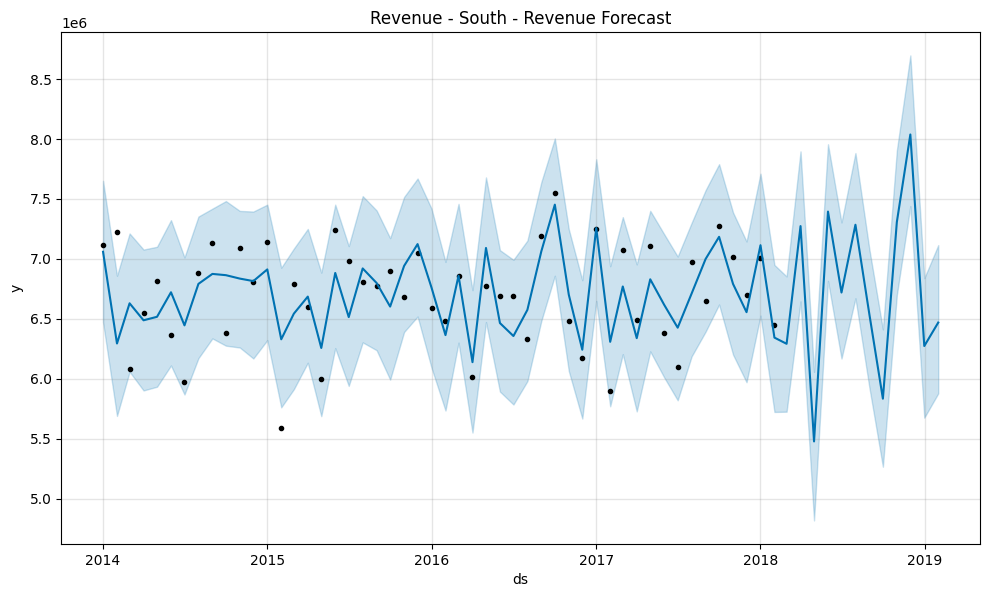


=== Revenue - South Forecast ===
Next 3 Months Expected Revenue: $19,041,877
Next 6 Months Expected Revenue: $40,438,311
Next 12 Months Expected Revenue: $80,892,853


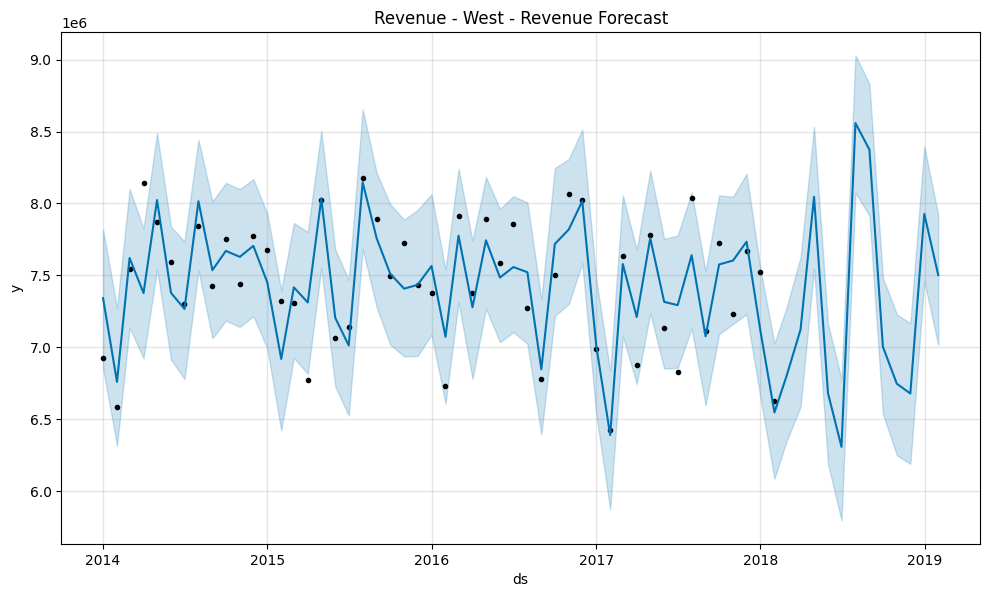


=== Revenue - West Forecast ===
Next 3 Months Expected Revenue: $21,966,899
Next 6 Months Expected Revenue: $43,511,601
Next 12 Months Expected Revenue: $87,737,667


In [82]:
from prophet import Prophet

def forecast_kpi(data, periods=12, freq='M', title=""):
    """Reusable forecasting function"""
    df_prophet = data.rename(columns={'year_month': 'ds', 'revenue': 'y'})


    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        interval_width=0.95
    )
    model.fit(df_prophet)

    future = model.make_future_dataframe(periods=periods, freq=freq)
    forecast = model.predict(future)

    # Plot
    fig = model.plot(forecast)
    plt.title(f'{title} - Revenue Forecast')
    plt.show()

    # Extract forecast
    future_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods)

    print(f"\n=== {title} Forecast ===")
    print(f"Next 3 Months Expected Revenue: ${future_forecast.head(3)['yhat'].sum():,.0f}")
    print(f"Next 6 Months Expected Revenue: ${future_forecast.head(6)['yhat'].sum():,.0f}")
    print(f"Next 12 Months Expected Revenue: ${future_forecast['yhat'].sum():,.0f}")

    return forecast

# Run forecasts
total_forecast = forecast_kpi(monthly_total, periods=12, title="Total Company Revenue")
region_forecasts = {}
for region in monthly_by_region['region'].unique():
    region_data = monthly_by_region[monthly_by_region['region'] == region]
    region_forecasts[region] = forecast_kpi(region_data, periods=12, title=f"Revenue - {region}")

In [87]:
# Correlation #OR
yz.groupby('region')['unit_price'].corr(yz['revenue'])

,unit_price
region,
Midwest,0.909998
Northeast,0.908642
South,0.909574
West,0.908687


In [93]:
### Data only accounts year 2014 as the only year with population.
### revenue_per_capita is impossible for this data. it can therefore be ignored or removed

In [94]:
# channel, product in a specific region
yz.loc[(yz['region'] == 'Midwest')&(yz['channel'] == 'Export')&(yz['product_name'] == 'Product 23')].head(1)
#


,order_number,order_date,customer_name,channel,product_name,order_quantity,unit_price,revenue,cost,state_code,...,day,quarter,year_month,population,month_short,gross_profit,expected_revenue,revenue_diff,revenue_per_capita,order_value
5,SO - 0010394,2014-01-01,Zoovu Corp,Export,Product 23,11,5219.3,57412.3,4332.019,MN,...,2,2014Q1,2014-01,190582.0,Jan,53080.281,57412.3,0.0,0.301247,57412.3


In [95]:
yz.to_csv('output_data.csv', index=False)
#